In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img_nama = cv2.imread('./assets/PCD_UTS_NAME.jpeg') 
img_rgb = cv2.cvtColor(img_nama, cv2.COLOR_BGR2RGB)

In [3]:
img_hsv = cv2.cvtColor(img_nama, cv2.COLOR_BGR2HSV)

In [4]:
# Range Warna Biru
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([140, 255, 255])

In [5]:
# Range Warna Merah
lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])

In [6]:
# Range Warna Hijau
lower_green = np.array([40, 50, 50])
upper_green = np.array([80, 255, 255])

In [7]:
mask_blue = cv2.inRange(img_hsv, lower_blue, upper_blue)
mask_red1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask_red2 = cv2.inRange(img_hsv, lower_red2, upper_red2)
mask_red = cv2.bitwise_or(mask_red1, mask_red2)
mask_green = cv2.inRange(img_hsv, lower_green, upper_green)

In [8]:
res_blue = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_blue)
res_red = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_red)
res_green = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_green)

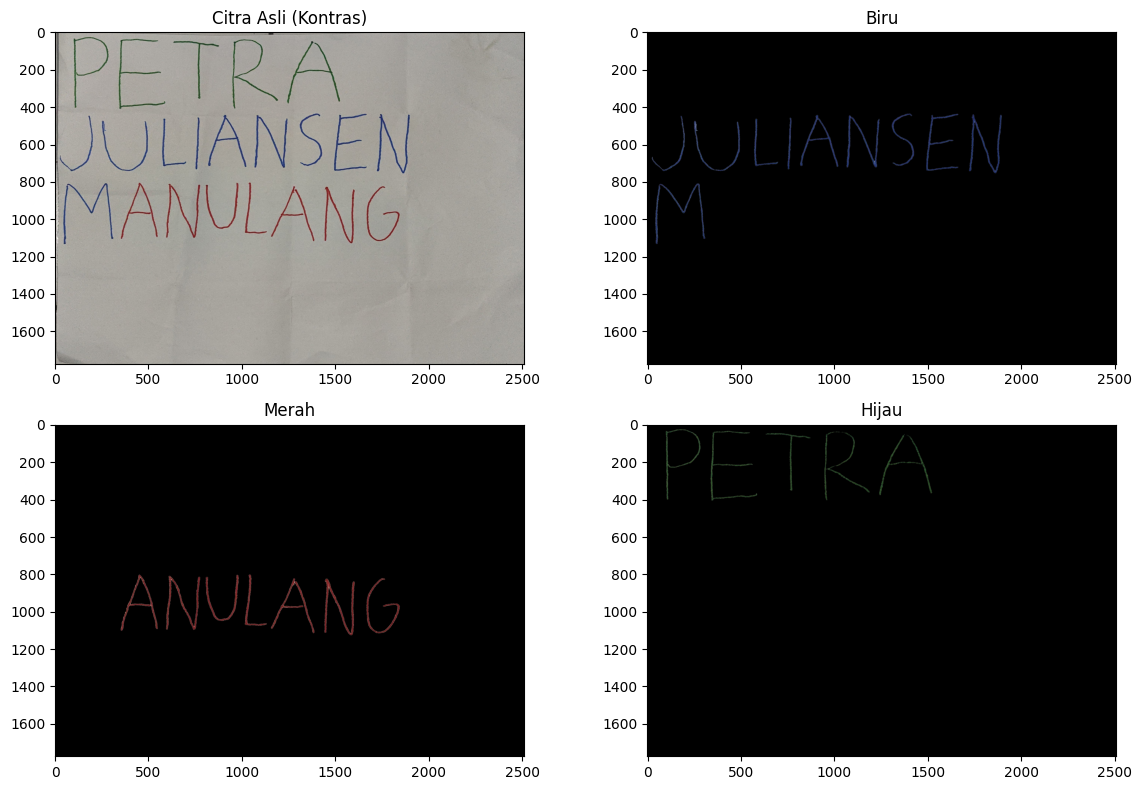

In [9]:
plt.figure(figsize=(12, 8))
plt.subplot(221), plt.imshow(img_rgb), plt.title('Citra Asli (Kontras)')
plt.subplot(222), plt.imshow(res_blue), plt.title('Biru')
plt.subplot(223), plt.imshow(res_red), plt.title('Merah')
plt.subplot(224), plt.imshow(res_green), plt.title('Hijau')
plt.tight_layout()
plt.show()

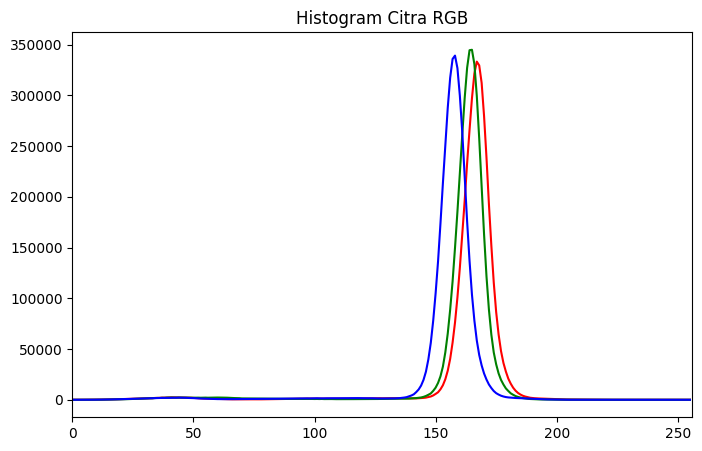

In [10]:
color = ('r','g','b')
plt.figure(figsize=(8, 5))
for i, col in enumerate(color):
    histr = cv2.calcHist([img_rgb],[i],None,[256],[0,256])
    plt.plot(histr, color=col)
    plt.xlim([0,256])
plt.title('Histogram Citra RGB')
plt.show()

In [11]:
mask_none = np.zeros_like(mask_blue)
mask_red_blue = cv2.bitwise_or(mask_red, mask_blue)
mask_all = cv2.bitwise_or(mask_red_blue, mask_green)

res_none = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_none)
res_red_blue = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_red_blue)
res_all = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_all)

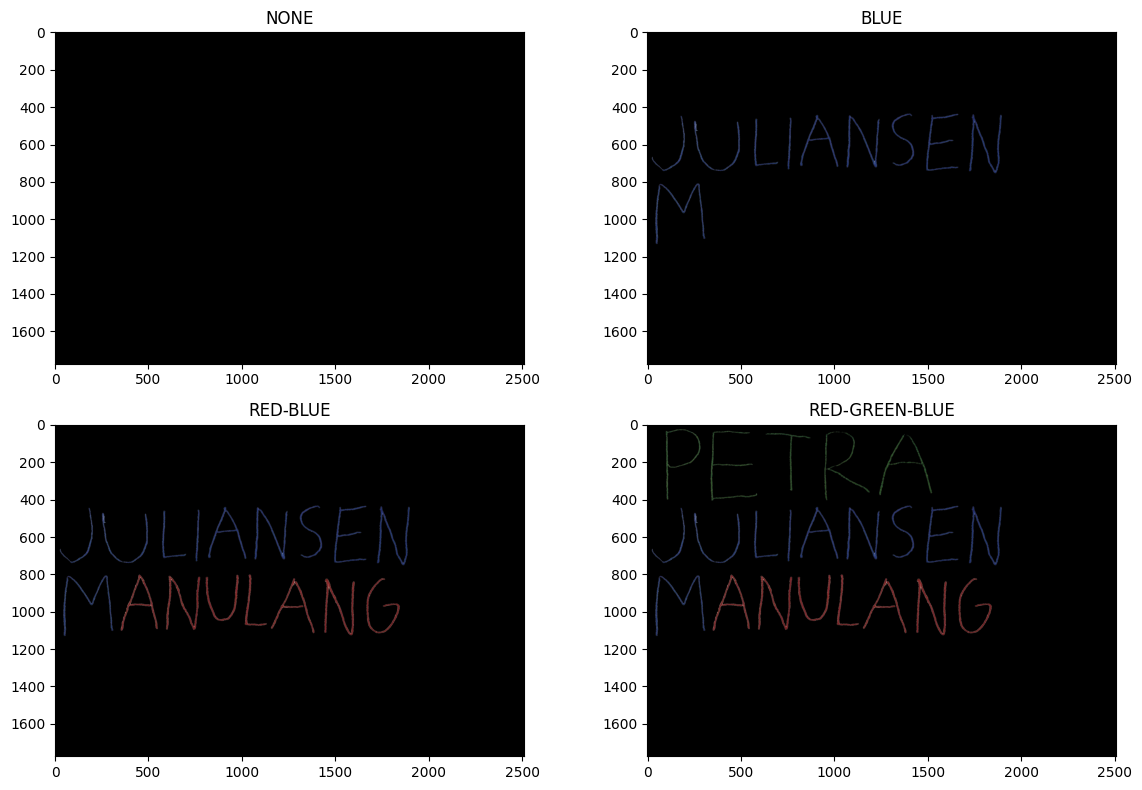

In [12]:
plt.figure(figsize=(12, 8))
plt.subplot(221), plt.imshow(res_none), plt.title('NONE')
plt.subplot(222), plt.imshow(res_blue), plt.title('BLUE')
plt.subplot(223), plt.imshow(res_red_blue), plt.title('RED-BLUE')
plt.subplot(224), plt.imshow(res_all), plt.title('RED-GREEN-BLUE')
plt.tight_layout()
plt.show()